# MGFR Prompt Generator — Kaggle
Runs the full prompt generation pipeline on CelebA test set using the
fine-tuned ResNet-50 classifier. Outputs `prompts_output.json` with
`pos`, `na`, `nq` prompts for every image.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'kagglehub', 'torch', 'torchvision', 'numpy', 'Pillow', 'tqdm'],
               check=True)

import os, json
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import kagglehub

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Config

In [2]:
# Path to your uploaded fine-tuned weights
# Add celeba_resnet50_finetuned.pth as a Kaggle dataset input, then set path:
WEIGHTS_PATH = '/kaggle/input/datasets/hannasamuel/celeba-finetuned/celeba_resnet50_finetuned_new.pth'

BATCH_SIZE   = 128     # increase to 256 if VRAM allows
NUM_WORKERS  = 4
POS_THRESHOLD = 0.6    # paper Section 4.1
NEG_THRESHOLD = 0.4
SPLIT        = 'test'  # 'test' | 'all' — which images to generate prompts for
OUTPUT_JSON  = 'prompts_output.json'

assert os.path.exists(WEIGHTS_PATH), (
    f'Weights not found at {WEIGHTS_PATH}\n'
    'Add your .pth file as a dataset input via the Kaggle sidebar.'
)
print(f'Weights: {os.path.getsize(WEIGHTS_PATH)/1e6:.1f} MB')

Weights: 94.7 MB


## Download CelebA

In [3]:
FFHQ_PATH = '/kaggle/input/datasets/hannasamuel/ffhqr-dataset/images512x512'

IMG_DIR = FFHQ_PATH
img_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))
])

assert len(img_files) > 0, f'No images found in {IMG_DIR}'
print(f'Images : {IMG_DIR}')
print(f'N imgs : {len(img_files)}')
print(f'Sample : {img_files[:5]}')

# Use all images as filenames (no train/val/test split needed for FFHQ)
filenames = img_files

Images : /kaggle/input/datasets/hannasamuel/ffhqr-dataset/images512x512
N imgs : 70000
Sample : ['00000.png', '00001.png', '00002.png', '00003.png', '00004.png']


## Attribute definitions

In [4]:
# CelebA-40 column order (must match training)
CELEBA_40 = [
    '5_o_Clock_Shadow','Arched_Eyebrows','Attractive','Bags_Under_Eyes',
    'Bald','Bangs','Big_Lips','Big_Nose','Black_Hair','Blond_Hair',
    'Blurry','Brown_Hair','Bushy_Eyebrows','Chubby','Double_Chin',
    'Eyeglasses','Goatee','Gray_Hair','Heavy_Makeup','High_Cheekbones',
    'Male','Mouth_Slightly_Open','Mustache','Narrow_Eyes','No_Beard',
    'Oval_Face','Pale_Skin','Pointy_Nose','Receding_Hairline','Rosy_Cheeks',
    'Sideburns','Smiling','Straight_Hair','Wavy_Hair','Wearing_Earrings',
    'Wearing_Hat','Wearing_Lipstick','Wearing_Necklace','Wearing_Necktie','Young',
]

# Paper's 28 attributes → CelebA-40 column names
PAPER_28_TO_CELEBA40 = {
    'Black Hair':'Black_Hair', 'Blond Hair':'Blond_Hair', 'Blurry':'Blurry',
    'Brown Hair':'Brown_Hair', 'Eyeglasses':'Eyeglasses', 'Gray Hair':'Gray_Hair',
    'Heavy Makeup':'Heavy_Makeup', 'Mouth Slightly Open':'Mouth_Slightly_Open',
    'Mustache':'Mustache', 'Big Eyes':'Narrow_Eyes',  # Big Eyes = NOT Narrow_Eyes
    'No Beard':'No_Beard', 'Receding Hairline':'Receding_Hairline',
    'Sideburns':'Sideburns', 'Smiling':'Smiling', 'Straight Hair':'Straight_Hair',
    'Wearing Earrings':'Wearing_Earrings', 'Wearing Hat':'Wearing_Hat', 'Male':'Male',
    'Wearing Necklace':'Wearing_Necklace', 'Big Nose':'Big_Nose',
    'Wearing Lipstick':'Wearing_Lipstick', 'Young':'Young', 'Wavy Hair':'Wavy_Hair',
    'Big Lips':'Big_Lips', 'Bald':'Bald', 'Bangs':'Bangs',
    'Chubby':'Chubby', 'Double Chin':'Double_Chin',
}
PAPER_28     = list(PAPER_28_TO_CELEBA40.keys())
C40_IDX      = {n: i for i, n in enumerate(CELEBA_40)}
ATTR_28_IDX  = [C40_IDX[PAPER_28_TO_CELEBA40[a]] for a in PAPER_28]
INVERT_IDX   = [i for i, a in enumerate(PAPER_28) if a == 'Big Eyes']
print(f'{len(PAPER_28)} paper attributes defined.')

28 paper attributes defined.


## Parse label file and select split

In [5]:
# FFHQ has no attribute labels — we are generating prompts, not evaluating
# filenames already set above, no split needed
print(f'Processing {len(filenames)} FFHQ images.')

Processing 70000 FFHQ images.


## Dataset and DataLoader

In [6]:
class FaceDataset(Dataset):
    def __init__(self, filenames, img_dir, transform):
        self.filenames = filenames
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        try:
            img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
            return self.transform(img), fname
        except Exception:
            return torch.zeros(3, 224, 224), fname


transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

dataset = FaceDataset(filenames, IMG_DIR, transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=True)
print(f'Batches: {len(loader)}')

Batches: 547


## Load fine-tuned classifier

In [7]:
# The fine-tuned model uses nn.Linear(2048, 40) — a single FC layer
# matching torchvision ResNet-50 architecture exactly
state   = torch.load(WEIGHTS_PATH, map_location=DEVICE)
fc_out  = state['fc.weight'].shape[0]   # 40 (trained on all40 mode)
print(f'FC output size: {fc_out}')

model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, fc_out)
model.load_state_dict(state, strict=True)
model.to(DEVICE).eval()
print('Model loaded.')

# Quick sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = torch.sigmoid(model(dummy))
print(f'Forward pass OK — output shape: {out.shape}')

FC output size: 40
Model loaded.
Forward pass OK — output shape: torch.Size([2, 40])


## Run classifier on all images

In [8]:
all_probs  = []   # (N, 40) float32
all_fnames = []

with torch.no_grad():
    for imgs, fnames in tqdm(loader, desc='Classifying'):
        imgs  = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.append(probs)
        all_fnames.extend(fnames)

all_probs = np.vstack(all_probs)   # (N, 40)

# Slice to paper's 28 attributes
probs_28 = all_probs[:, ATTR_28_IDX].copy()   # (N, 28)
for idx in INVERT_IDX:
    probs_28[:, idx] = 1.0 - probs_28[:, idx]  # Big Eyes = 1 - Narrow_Eyes

print(f'Inference done. Shape: {probs_28.shape}')

Classifying:   0%|          | 0/547 [00:00<?, ?it/s]

Inference done. Shape: (70000, 28)


## Prompt generation functions

In [13]:
QUALITY_PREFIX = (
    'A high quality, high resolution, realistic and extremely detailed image'
)
NEGATIVE_QUALITY_PROMPT = (
    'A low quality, low resolution, over smooth and deformation image.'
)


def format_attr_list_as_person(attrs):
    """Phrases attributes as a person description for Prompt B."""
    if not attrs:
        return ''
    
    PERSON_ATTRS = {'Male': 'old man', 'Young': 'young', 'Chubby': 'chubby'}
    # For Prompt B, Male→ 'old man', absence of Young → implied older
    
    person  = [PERSON_ATTRS[a] for a in attrs if a in PERSON_ATTRS]
    feature = [a.lower() for a in attrs if a not in PERSON_ATTRS]
    
    parts = []
    subject = ' '.join(person) if person else 'a person'
    if not person:
        parts.append(subject)
    else:
        parts.append(f'a {subject}')
    if feature:
        parts.append(f'who has {", ".join(feature)}')
    
    return ' '.join(parts)


def make_prompts(probs_row):
    pos_attrs = [PAPER_28[i] for i, p in enumerate(probs_row) if p > POS_THRESHOLD]
    neg_attrs = [PAPER_28[i] for i, p in enumerate(probs_row) if p < NEG_THRESHOLD]

    # Prompt A — "in the description of" + positive attributes
    if pos_attrs:
        pos_desc   = format_attr_list(pos_attrs)
        pos_prompt = f'{QUALITY_PREFIX} in the description of {pos_desc}.'
    else:
        pos_prompt = f'{QUALITY_PREFIX}.'

    # Prompt B — "not in the description of" + NEGATIVE attributes phrased as a person
    if neg_attrs:
        na_desc   = format_attr_list_as_person(neg_attrs)
        na_prompt = f'{QUALITY_PREFIX} not in the description of {na_desc}.'
    else:
        na_prompt = f'{QUALITY_PREFIX}.'

    return {
        'pos': pos_prompt,
        'na':  na_prompt,
        'nq':  NEGATIVE_QUALITY_PROMPT,
        'positive_attrs': pos_attrs,
        'negative_attrs': neg_attrs,
    }

## Generate prompts for all images

In [14]:
results = []
for fname, probs_row in tqdm(zip(all_fnames, probs_28),
                              total=len(all_fnames), desc='Generating prompts'):
    entry = make_prompts(probs_row)
    entry['image'] = fname
    # Store per-attribute probabilities rounded to 3 dp
    entry['probabilities'] = {
        attr: round(float(p), 3)
        for attr, p in zip(PAPER_28, probs_row)
    }
    results.append(entry)

print(f'Generated prompts for {len(results)} images.')

# Preview first result
r = results[0]
print(f'\nSample — {r["image"]}')
print(f'  pos attrs : {r["positive_attrs"]}')
print(f'  pos       : {r["pos"]}')
print(f'  na        : {r["na"]}')
print(f'  nq        : {r["nq"]}')

Generating prompts:   0%|          | 0/70000 [00:00<?, ?it/s]

Generated prompts for 70000 images.

Sample — 00000.png
  pos attrs : ['Big Eyes', 'No Beard', 'Straight Hair', 'Young']
  pos       : A high quality, high resolution, realistic and extremely detailed image in the description of young who has big eyes, no beard, straight hair.
  na        : A high quality, high resolution, realistic and extremely detailed image not in the description of a old man chubby who has black hair, blond hair, blurry, brown hair, eyeglasses, gray hair, heavy makeup, mouth slightly open, mustache, receding hairline, sideburns, smiling, wearing earrings, wearing hat, wearing necklace, big nose, wearing lipstick, wavy hair, big lips, bald, bangs, double chin.
  nq        : A low quality, low resolution, over smooth and deformation image.


## Quick stats

Avg positive attrs per image : 6.1
Images with 0 positive attrs : 0 (0.0%)


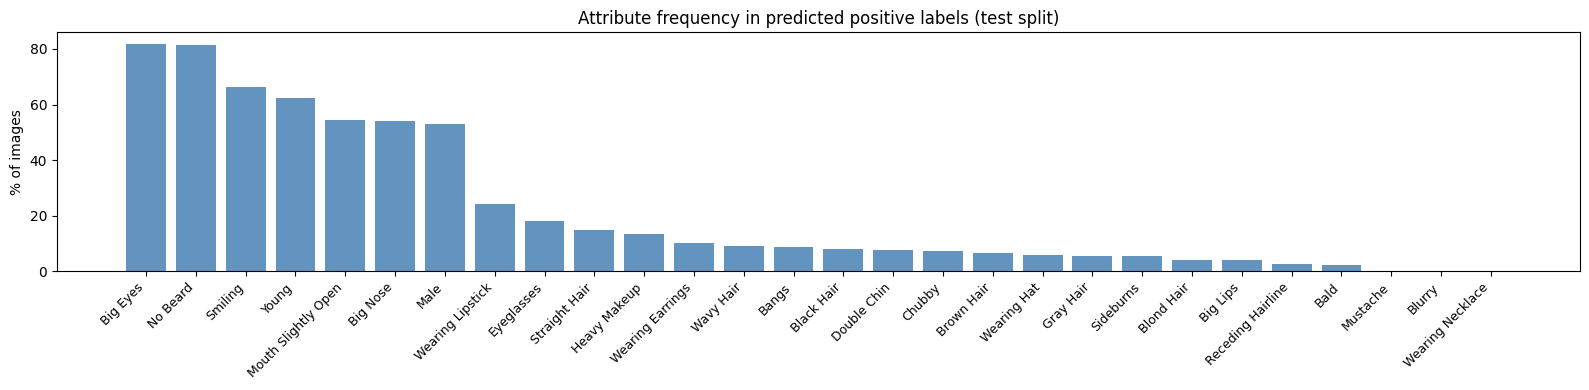

In [15]:
import matplotlib.pyplot as plt

n_pos_per_img  = [len(r['positive_attrs']) for r in results]
n_empty        = sum(1 for r in results if not r['positive_attrs'])

print(f'Avg positive attrs per image : {np.mean(n_pos_per_img):.1f}')
print(f'Images with 0 positive attrs : {n_empty} ({n_empty/len(results)*100:.1f}%)')

# Attribute frequency
attr_freq = {a: 0 for a in PAPER_28}
for r in results:
    for a in r['positive_attrs']:
        attr_freq[a] += 1

sorted_attrs = sorted(attr_freq, key=attr_freq.get, reverse=True)
freqs = [attr_freq[a]/len(results)*100 for a in sorted_attrs]

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(PAPER_28)), freqs, color='steelblue', alpha=0.85)
ax.set_xticks(range(len(PAPER_28)))
ax.set_xticklabels(sorted_attrs, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of images')
ax.set_title(f'Attribute frequency in predicted positive labels ({SPLIT} split)')
plt.tight_layout()
plt.savefig('attr_frequency.png', dpi=150)
plt.show()

## Save output JSON

In [16]:
with open(OUTPUT_JSON, 'w') as f:
    json.dump(results, f, indent=2)

size_mb = os.path.getsize(OUTPUT_JSON) / 1e6
print(f'Saved {len(results)} entries → {OUTPUT_JSON}  ({size_mb:.1f} MB)')
print('Download from the Kaggle output panel.')

Saved 70000 entries → prompts_output.json  (141.4 MB)
Download from the Kaggle output panel.
